In [7]:
# --------------------
# Adversarial training utilities (FGSM/PGD)
# --------------------
import torch

# Toggle and hyperparameters
ADV_TRAIN = False           # disabled for speed — just visualising Hessian spectrum
ADV_METHOD = "fgsm"          # "fgsm" or "pgd"
ADV_EPS = 0.3               # in [0,1] pixel space
ADV_ALPHA = 0.01            # step size in [0,1] pixel space
ADV_STEPS = 10              # PGD iterations
ADV_RANDOM_START = True


def _get_mean_std_tensors(inputs: torch.Tensor):
    """Return per-channel mean/std tensors on the same device as inputs.
    Falls back to MNIST defaults if globals not yet defined.
    """
    mean = globals().get('mnist_mean', (0.1307,))
    std = globals().get('mnist_std', (0.3081,))
    mean_t = torch.as_tensor(mean, device=inputs.device, dtype=inputs.dtype).view(1, -1, 1, 1)
    std_t = torch.as_tensor(std, device=inputs.device, dtype=inputs.dtype).view(1, -1, 1, 1)
    return mean_t, std_t


def _normalize_img_with_tensors(x: torch.Tensor, mean_t: torch.Tensor, std_t: torch.Tensor) -> torch.Tensor:
    return (x - mean_t) / std_t


def _denormalize_img_with_tensors(x: torch.Tensor, mean_t: torch.Tensor, std_t: torch.Tensor) -> torch.Tensor:
    return x * std_t + mean_t


def _autocast_kwargs(inputs: torch.Tensor):
    # Use runtime globals if available; otherwise default to safe values
    _amp_dtype = globals().get('amp_dtype', torch.float16)
    _autocast_enabled = globals().get('autocast_enabled', False)
    return dict(device_type=inputs.device.type, dtype=_amp_dtype, enabled=False)


def fgsm_attack(model: torch.nn.Module, inputs: torch.Tensor, labels: torch.Tensor, eps: float) -> torch.Tensor:
    """FGSM in pixel space with normalization-aware forward pass."""
    was_training = model.training
    model.eval()

    mean_t, std_t = _get_mean_std_tensors(inputs)
    x = _denormalize_img_with_tensors(inputs.detach(), mean_t, std_t)
    x.requires_grad_(True)

    # Always compute attacks in full precision for stability
    with torch.autocast(**_autocast_kwargs(inputs)):
        logits = model(_normalize_img_with_tensors(x, mean_t, std_t))
        loss = criterion(logits, labels)

    grad = torch.autograd.grad(loss, x, retain_graph=False, create_graph=False)[0]
    x_adv = x + eps * grad.sign()
    x_adv = x_adv.clamp(0.0, 1.0)

    if was_training:
        model.train()
    return _normalize_img_with_tensors(x_adv, mean_t, std_t).detach()


def pgd_attack(
    model: torch.nn.Module,
    inputs: torch.Tensor,
    labels: torch.Tensor,
    eps: float,
    alpha: float,
    steps: int,
    random_start: bool = True,
) -> torch.Tensor:
    """L-infinity PGD in pixel space, projected around the original image."""
    was_training = model.training
    model.eval()

    mean_t, std_t = _get_mean_std_tensors(inputs)
    x0 = _denormalize_img_with_tensors(inputs.detach(), mean_t, std_t)

    if random_start:
        x = x0 + torch.empty_like(x0).uniform_(-eps, eps)
    else:
        x = x0.clone()
    x = x.clamp(0.0, 1.0)

    for _ in range(steps):
        x.requires_grad_(True)
        # Always compute attacks in full precision for stability
        with torch.autocast(**_autocast_kwargs(inputs)):
            logits = model(_normalize_img_with_tensors(x, mean_t, std_t))
            loss = criterion(logits, labels)
        grad = torch.autograd.grad(loss, x, retain_graph=False, create_graph=False)[0]
        x = x + alpha * grad.sign()
        x = torch.max(torch.min(x, x0 + eps), x0 - eps)
        x = x.clamp(0.0, 1.0).detach()

    if was_training:
        model.train()
    return _normalize_img_with_tensors(x, mean_t, std_t).detach()


def generate_adversarial_examples(model: torch.nn.Module, inputs: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    if not ADV_TRAIN:
        return inputs
    method = str(ADV_METHOD).lower()
    if method == 'fgsm':
        return fgsm_attack(model, inputs, labels, ADV_EPS)
    # default to PGD
    return pgd_attack(model, inputs, labels, ADV_EPS, ADV_ALPHA, ADV_STEPS, ADV_RANDOM_START)



Using device: mps
[DST] Stage 1: dense training for 5 epochs...
Epoch 1/10 | Train Loss: 0.9296 | Train Acc: 83.24% | Test Loss: — | Test Acc: —
Epoch 2/10 | Train Loss: 0.5544 | Train Acc: 98.56% | Test Loss: — | Test Acc: —
Epoch 3/10 | Train Loss: 0.5373 | Train Acc: 99.00% | Test Loss: — | Test Acc: —
Epoch 4/10 | Train Loss: 0.5263 | Train Acc: 99.25% | Test Loss: — | Test Acc: —
Epoch 5/10 | Train Loss: 0.5189 | Train Acc: 99.47% | Test Loss: 0.5138 | Test Acc: 99.61%
[DST] Pruned ~90.0% globally (threshold=4.290e-02). Current sparsity: 89.74% (242841/270608 zeros in Conv/FC).
[SLQ] DST schedule: start at step 585, interval 100
[DST] Stage 2: dynamic-sparse training for 5 epochs...
[SLQ] starting: probes=5, lanczos=10, batch=32
[SLQ] step 685 | grid=[-2.362e+01,1.561e+02] | avg density=5.509e-03
Epoch 6/10 | Train Loss: 0.5632 | Train Acc: 98.54% | Test Loss: — | Test Acc: —
[SLQ] starting: probes=5, lanczos=10, batch=32
[SLQ] step 785 | grid=[-2.587e+00,7.699e+01] | avg density=

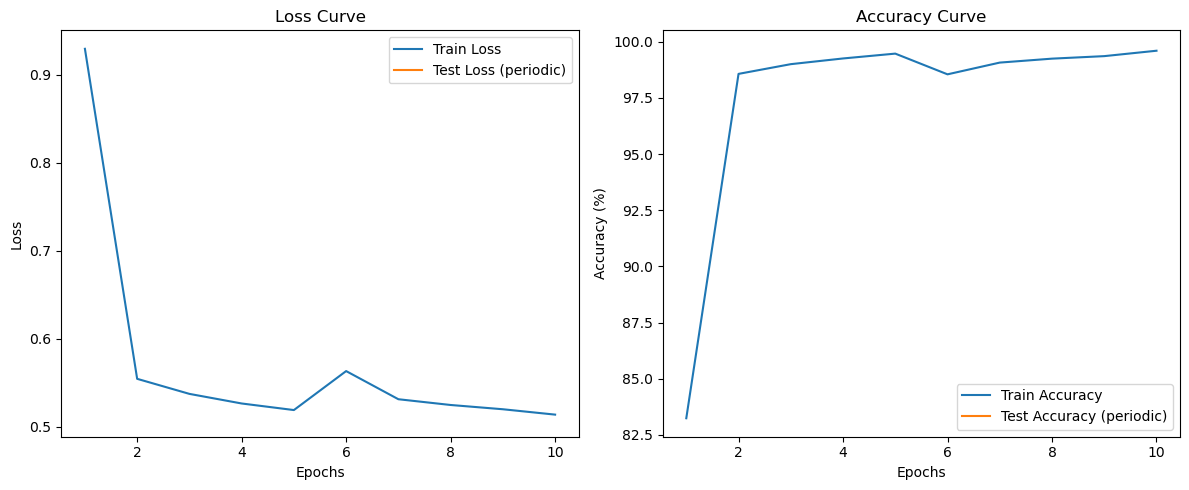

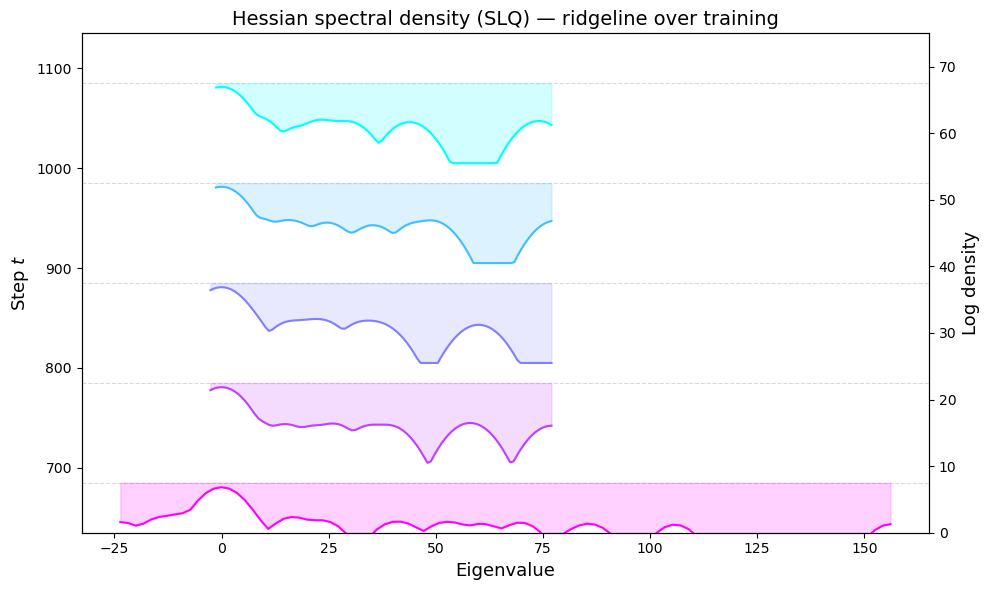

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    _HAVE_SNS = True
except Exception:
    _HAVE_SNS = False
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets

# --------------------
# Device selection (MPS -> CUDA -> CPU)
# --------------------
def get_device():
    try:
        if torch.backends.mps.is_available() and torch.backends.mps.is_built():
            return torch.device("mps")
    except Exception:
        pass
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

if __name__ == "__main__":
    device = get_device()
    print("Using device:", device)

    # Safer multiprocessing on macOS/Windows
    import multiprocessing as mp
    try:
        mp.set_start_method("spawn", force=True)
    except RuntimeError:
        pass

    # Seeds
    torch.manual_seed(0); np.random.seed(0); random.seed(0)

    use_cuda = (device.type == "cuda")
    use_mps  = (device.type == "mps")

    # CUDA-specific speed toggles
    if use_cuda:
        torch.backends.cudnn.benchmark = True
        try:
            torch.set_float32_matmul_precision("high")  # TF32 on Ampere+
        except Exception:
            pass

    # --------------------
    # CIFAR ResNet-20
    # --------------------
    class BasicBlock(nn.Module):
        expansion = 1
        def __init__(self, in_planes, planes, stride=1):
            super().__init__()
            self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
            self.bn1 = nn.BatchNorm2d(planes)
            self.relu = nn.ReLU(inplace=True)
            self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
            self.bn2 = nn.BatchNorm2d(planes)
            self.shortcut = nn.Sequential()
            if stride != 1 or in_planes != planes * self.expansion:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_planes, planes * self.expansion, 1, stride, bias=False),
                    nn.BatchNorm2d(planes * self.expansion),
                )
        def forward(self, x):
            out = self.relu(self.bn1(self.conv1(x)))
            out = self.bn2(self.conv2(out))
            out = out + self.shortcut(x)
            out = self.relu(out)
            return out

    class ResNet(nn.Module):
        def __init__(self, block, num_blocks, num_classes=10, base_width=16):
            super().__init__()
            self.in_planes = base_width
            self.conv1 = nn.Conv2d(1, base_width, 3, 1, 1, bias=False)
            self.bn1 = nn.BatchNorm2d(base_width)
            self.relu = nn.ReLU(inplace=True)
            self.layer1 = self._make_layer(block, base_width, num_blocks[0], stride=1)
            self.layer2 = self._make_layer(block, base_width * 2, num_blocks[1], stride=2)
            self.layer3 = self._make_layer(block, base_width * 4, num_blocks[2], stride=2)
            self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            self.fc = nn.Linear(base_width * 4 * block.expansion, num_classes)

        def _make_layer(self, block, planes, blocks, stride):
            strides = [stride] + [1] * (blocks - 1)
            layers = []
            for s in strides:
                layers.append(block(self.in_planes, planes, s))
                self.in_planes = planes * block.expansion
            return nn.Sequential(*layers)

        def forward(self, x):
            out = self.relu(self.bn1(self.conv1(x)))
            out = self.layer1(out)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.avgpool(out)
            out = torch.flatten(out, 1)
            out = self.fc(out)
            return out

    def ResNet20(num_classes=10, base_width=16):
        return ResNet(BasicBlock, [3, 3, 3], num_classes=num_classes, base_width=base_width)

    # --------------------
    # Data transforms
    # --------------------
    mnist_mean = (0.1307,)
    mnist_std  = (0.3081,)

    # Simpler aug for MNIST
    randaugment = []

    transform_train = transforms.Compose([
        transforms.RandomCrop(28, padding=2),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mnist_mean, mnist_std),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mnist_mean, mnist_std),
    ])

    # --------------------
    # Datasets
    # --------------------
    train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform_train)
    test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform_test)

    # --------------------
    # DataLoaders (macOS/MPS safe)
    # --------------------
    BATCH_TRAIN = 512 if use_cuda else (512 if use_mps else 512)
    BATCH_TEST  = 1024 if use_cuda else (1024 if use_mps else 1024)
    DROP_LAST   = True

    num_workers = 0 if use_mps else min(4, os.cpu_count() or 4)

    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed); random.seed(worker_seed)
    g = torch.Generator(); g.manual_seed(0)

    train_loader_kwargs = dict(
        dataset=train_dataset, batch_size=BATCH_TRAIN, shuffle=True,
        num_workers=num_workers, pin_memory=use_cuda, drop_last=DROP_LAST
    )
    test_loader_kwargs = dict(
        dataset=test_dataset, batch_size=BATCH_TEST, shuffle=False,
        num_workers=num_workers, pin_memory=use_cuda, drop_last=False
    )
    if num_workers > 0:
        train_loader_kwargs.update(
            dict(persistent_workers=True, prefetch_factor=4,
                 worker_init_fn=seed_worker, generator=g)
        )
        test_loader_kwargs.update(
            dict(persistent_workers=True, prefetch_factor=2,
                 worker_init_fn=seed_worker, generator=g)
        )

    train_loader = DataLoader(**train_loader_kwargs)
    test_loader  = DataLoader(**test_loader_kwargs)

    # A fixed, augmentation-free batch for Hessian estimation (first test batch)
    hess_inputs_cpu, hess_labels_cpu = next(iter(test_loader))

    # --------------------
    # Model, compile, memory format
    # --------------------
    model = ResNet20(num_classes=10, base_width=16).to(device)

    if use_cuda or use_mps:
        model = model.to(memory_format=torch.channels_last)

    if use_cuda:
        try:
            import torch._dynamo as dynamo
            dynamo.config.suppress_errors = True  # if compile fails, fall back to eager
            model = torch.compile(model, mode="max-autotune")
        except Exception:
            pass  # run eager

    # --------------------
    # Schedules, EMA, AMP defaults
    # --------------------
    from torch.optim.swa_utils import AveragedModel, update_bn
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    USE_ONECYCLE = True
    NUM_EPOCHS = 10  # reduced — just enough to see Hessian spectrum
    BASE_BS, BASE_MAX_LR = 256, 0.2
    scaled_max_lr = BASE_MAX_LR * (BATCH_TRAIN / BASE_BS) ** 0.5


    if use_cuda and hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported():
        amp_dtype = torch.bfloat16
    elif use_mps:
        amp_dtype = torch.float16
    else:
        amp_dtype = torch.float16  # unused on CPU

    # For numerical stability on MPS, disable autocast; keep it on CUDA
    autocast_enabled = use_cuda
    # (scaler will be instantiated per-stage below)

    ema = AveragedModel(model, avg_fn=lambda avg_p, p, n: 0.999 * avg_p + 0.001 * p)

    # --------------------
    # Dynamic Sparse Training (DST): config + utilities
    # --------------------
    DST_ENABLED          = True
    DST_TARGET_SPARSITY  = 0.9   # start milder (85%) to preserve capacity early
    DST_PRETRAIN_EPOCHS  = 5        # dense warmup epochs (out of NUM_EPOCHS)
    DST_SKIP_FIRST_LAST  = True     # avoid pruning the input and final layers for stability

    def _prunable_weight_params(model):
        """Conv/Linear weights only (no BN/bias)."""
        params = []
        for m in model.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                params.append(m.weight)
        return params

    @torch.no_grad()
    def global_magnitude_prune_(model, sparsity, skip_first_last=DST_SKIP_FIRST_LAST):
        """In-place global magnitude pruning: set the smallest |w| weights to 0. No mask kept."""
        params = _prunable_weight_params(model)
        if skip_first_last and len(params) >= 2:
            params_to_prune = params[1:-1]
        else:
            params_to_prune = params
        if not params_to_prune:
            return 0.0, 0, 0
        all_abs = torch.cat([p.detach().abs().flatten().cpu() for p in params_to_prune])
        thr = torch.quantile(all_abs, sparsity)
        pruned = total = 0
        for p in params_to_prune:
            mask = (p.detach().abs() <= thr.to(p.device))
            pruned += int(mask.sum().item())
            total  += mask.numel()
            p.data.masked_fill_(mask, 0)
        return float(thr), pruned, total

    def count_zeros_and_total(model):
        zeros = total = 0
        for p in _prunable_weight_params(model):
            total += p.numel()
            zeros += int((p == 0).sum().item())
        return zeros, total

    # --------------------
    # Hessian extrema via Lanczos (HVPs with autograd)
    # --------------------
    HESSIAN_EVERY = 10**9        # epochs (effectively disabled; using SLQ at specific steps)
    HESSIAN_STEPS = 20        # Lanczos steps (trade speed/accuracy)

    hess_epochs, hess_lmin, hess_lmax, hess_spread = [], [], [], []  # legacy; keep for compatibility

    # --- SLQ spectral density config ---
    SLQ_INTERVAL = 100                               # constant step interval (global) after pruning
    SLQ_START_STEP = None                            # set right after pruning
    SLQ_NUM_PROBES  = 15                             # Hutchinson probes (reduce for speed)
    SLQ_NUM_LANCZOS = 20                             # Lanczos steps per probe (reduce for speed)
    SLQ_SPECTRUM_BINS = 256                         # discretization bins
    SLQ_LOG_DENSITY = True                           # plot log-density
    HESS_SUBSAMPLE = 64                              # use only first N samples from fixed batch for SLQ

    # Device-specific downscaling (MPS second-order autograd is slower)
    if device.type == "mps":
        SLQ_NUM_PROBES = 5
        SLQ_NUM_LANCZOS = 10
        SLQ_SPECTRUM_BINS = 100
        HESS_SUBSAMPLE = 32
        SLQ_INTERVAL = 100
        # MPS tends to be less stable with mixed precision; keep training in fp32
        autocast_enabled = False

    # Stable SLQ grid configuration
    SLQ_STABLE_GRID = True              # keep grid bounds monotonically narrowing
    SLQ_FIX_SIGMA = True                # fix kernel bandwidth over time
    SLQ_SIGMA_FRACTION = 0.01           # sigma as fraction of initial span (if fixed)
    SLQ_NORMALIZE_DENSITY = True        # normalize density to integrate to 1
    SLQ_LO_RUNNING = None               # running lower bound
    SLQ_HI_RUNNING = None               # running upper bound
    SLQ_SIGMA_FIXED = None              # fixed sigma value determined on first SLQ call

    slq_records = []   # list of dicts { 'step': t, 'eigs_grid': np.array, 'density': np.array }
    GLOBAL_STEP = 0


    def _flat_params(params):
        return sum(p.numel() for p in params)

    def _vector_to_parameters(vec, params):
        """Split flat vec into parameter-shaped tensors."""
        out, idx = [], 0
        for p in params:
            n = p.numel()
            out.append(vec[idx:idx+n].view_as(p))
            idx += n
        return out

    @torch.no_grad()
    def _to_device_fp32(x_cpu):
        return x_cpu.to(device=device, dtype=torch.float32, non_blocking=True)

    def estimate_hessian_extremal_eigs(model_, inputs_cpu, labels_cpu, steps=HESSIAN_STEPS):
        """
        Approximate min/max eigenvalues of the Hessian using Lanczos + autograd HVPs.
        Computed in FP32 on a fixed batch for stability.
        """
        was_training = model_.training
        model_.eval()

        inputs = _to_device_fp32(inputs_cpu)
        labels = labels_cpu.to(device, non_blocking=True)

        params = [p for p in model_.parameters() if p.requires_grad]
        dim = _flat_params(params)

        def hvp(v_flat):
            with torch.autocast(device_type=device.type, enabled=False):
                outputs = model_(inputs)
                loss = criterion(outputs, labels)
            grads = torch.autograd.grad(loss, params, create_graph=True)
            g_flat = torch.cat([g.contiguous().view(-1) for g in grads])
            dot = (g_flat * v_flat).sum()
            hv = torch.autograd.grad(dot, params, retain_graph=False)
            hv_flat = torch.cat([h.contiguous().view(-1) for h in hv])
            return hv_flat

        v = torch.randn(dim, device=device)
        v = v / (v.norm() + 1e-12)
        alphas, betas = [], []
        v_prev = torch.zeros_like(v)
        beta_prev = 0.0

        for k in range(steps):
            w = hvp(v)
            if k > 0:
                w = w - beta_prev * v_prev
            alpha = torch.dot(v, w)
            w = w - alpha * v
            beta = w.norm()

            alphas.append(alpha.item())
            betas.append(beta.item())

            if beta.item() < 1e-10:
                break
            v_prev, v = v, w / (beta + 1e-12)
            beta_prev = beta.item()

        m = len(alphas)
        T = np.zeros((m, m), dtype=np.float64)
        for i in range(m):
            T[i, i] = alphas[i]
            if i + 1 < m:
                T[i, i+1] = betas[i]
                T[i+1, i] = betas[i]
        evals = np.linalg.eigvalsh(T)
        lam_min = float(evals[0])
        lam_max = float(evals[-1])

        if was_training:
            model_.train()
        return lam_min, lam_max

    def slq_spectral_density(model_, inputs_cpu, labels_cpu,
                             num_probes=SLQ_NUM_PROBES,
                             num_lanczos=SLQ_NUM_LANCZOS,
                             grid_bins=SLQ_SPECTRUM_BINS):
        """
        Estimate Hessian spectral density via SLQ:
        - Multiple random probes
        - Lanczos tridiagonalization per probe
        - Average Gauss quadrature weights over a shared grid
        Returns eig_grid (shape [B]) and density (shape [B]).
        """
        was_training = model_.training
        model_.eval()

        # Subsample a small, fixed batch for speed
        inputs_cpu = inputs_cpu[:HESS_SUBSAMPLE]
        labels_cpu = labels_cpu[:HESS_SUBSAMPLE]

        inputs = _to_device_fp32(inputs_cpu)
        labels = labels_cpu.to(device, non_blocking=True)

        params = [p for p in model_.parameters() if p.requires_grad]
        dim = _flat_params(params)

        def hvp(v_flat):
            with torch.autocast(device_type=device.type, enabled=False):
                outputs = model_(inputs)
                loss = criterion(outputs, labels)
            grads = torch.autograd.grad(loss, params, create_graph=True)
            g_flat = torch.cat([g.contiguous().view(-1) for g in grads])
            dot = (g_flat * v_flat).sum()
            hv = torch.autograd.grad(dot, params, retain_graph=False)
            hv_flat = torch.cat([h.contiguous().view(-1) for h in hv])
            return hv_flat

        tri_alphas = []
        tri_betas = []

        print(f"[SLQ] starting: probes={num_probes}, lanczos={num_lanczos}, batch={len(inputs_cpu)}")
        for p in range(num_probes):
            v = torch.randn(dim, device=device)
            v = v / (v.norm() + 1e-12)
            alphas, betas = [], []
            v_prev = torch.zeros_like(v)
            beta_prev = 0.0

            for k in range(num_lanczos):
                w = hvp(v)
                if k > 0:
                    w = w - beta_prev * v_prev
                alpha = torch.dot(v, w)
                w = w - alpha * v
                beta = w.norm()

                alphas.append(alpha.item())
                betas.append(beta.item())

                if beta.item() < 1e-10:
                    break
                v_prev, v = v, w / (beta + 1e-12)
                beta_prev = beta.item()

            tri_alphas.append(alphas)
            tri_betas.append(betas)

        # Determine common spectral bounds from all probes' tridiagonals
        all_eigs = []
        for alphas, betas in zip(tri_alphas, tri_betas):
            m = len(alphas)
            T = np.zeros((m, m), dtype=np.float64)
            for i in range(m):
                T[i, i] = alphas[i]
                if i + 1 < m:
                    T[i, i+1] = betas[i]
                    T[i+1, i] = betas[i]
            evals = np.linalg.eigvalsh(T)
            all_eigs.append(evals)
        lam_lo = float(min(e[0] for e in all_eigs))
        lam_hi = float(max(e[-1] for e in all_eigs))

        # Stable grid bounds: monotonically narrowing across calls
        global SLQ_LO_RUNNING, SLQ_HI_RUNNING, SLQ_SIGMA_FIXED
        if SLQ_STABLE_GRID:
            if SLQ_LO_RUNNING is None or SLQ_HI_RUNNING is None:
                SLQ_LO_RUNNING, SLQ_HI_RUNNING = lam_lo, lam_hi
            else:
                SLQ_LO_RUNNING = max(SLQ_LO_RUNNING, lam_lo)
                SLQ_HI_RUNNING = min(SLQ_HI_RUNNING, lam_hi)
            lam_lo, lam_hi = SLQ_LO_RUNNING, SLQ_HI_RUNNING

        eig_grid = np.linspace(lam_lo, lam_hi, grid_bins)
        density = np.zeros_like(eig_grid)

        # Accumulate SLQ density from each probe using Gauss quadrature for its T
        for alphas, betas in zip(tri_alphas, tri_betas):
            m = len(alphas)
            T = np.zeros((m, m), dtype=np.float64)
            for i in range(m):
                T[i, i] = alphas[i]
                if i + 1 < m:
                    T[i, i+1] = betas[i]
                    T[i+1, i] = betas[i]
            evals, evecs = np.linalg.eigh(T)
            # First basis vector e1 determines quadrature weights (squared first component)
            w0 = evecs[0, :] ** 2
            # Place masses at evals and smooth with a Gaussian kernel
            if SLQ_FIX_SIGMA:
                if SLQ_SIGMA_FIXED is None:
                    initial_span = max(1e-12, (SLQ_HI_RUNNING - SLQ_LO_RUNNING) if SLQ_STABLE_GRID else (lam_hi - lam_lo))
                    SLQ_SIGMA_FIXED = max(1e-3, SLQ_SIGMA_FRACTION * initial_span)
                sigma = SLQ_SIGMA_FIXED
            else:
                sigma = max(1e-3, 0.01 * (lam_hi - lam_lo + 1e-12))
            for lam, weight in zip(evals, w0):
                density += weight * np.exp(-0.5 * ((eig_grid - lam) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)

        density /= max(1, len(tri_alphas))
        if SLQ_NORMALIZE_DENSITY:
            area = np.trapezoid(density, eig_grid)
            if area > 0:
                density = density / area

        if was_training:
            model_.train()
        return eig_grid, density

    # --------------------
    # 
    # 
    # /scheduler factory (per training phase)
    # --------------------
    def make_opt_sched(total_epochs, max_lr):
        # SGD with Nesterov, exclude BN/bias from weight decay
        bn_bias, rest = [], []
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if name.endswith('.bias') or 'bn' in name.lower():
                bn_bias.append(p)
            else:
                rest.append(p)
        opt = optim.SGD([
            {'params': rest, 'weight_decay': 5e-4},
            {'params': bn_bias, 'weight_decay': 0.0},
        ], lr=max_lr, momentum=0.9, nesterov=True)
        if USE_ONECYCLE:
            sch = torch.optim.lr_scheduler.OneCycleLR(
                opt, max_lr=max_lr, epochs=total_epochs,
                steps_per_epoch=len(train_loader),
                pct_start=0.1, div_factor=25.0, final_div_factor=100.0
            )
        else:
            sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_epochs)
        return opt, sch

    # --------------------
    # Metrics storage
    # --------------------
    train_losses, train_accuracies = [], []
    test_losses,  test_accuracies  = [], []

    # --------------------
    # Device transfer helper
    # --------------------
    def to_dev(inputs, labels):
        if use_cuda:
            inputs = inputs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)
        else:
            inputs, labels = inputs.to(device), labels.to(device)
            if use_mps:
                inputs = inputs.to(memory_format=torch.channels_last)
        return inputs, labels

    # --------------------
    # Eval helper (sample-weighted)
    # --------------------
    @torch.inference_mode()
    def evaluate(model_, loader):
        model_.eval()
        loss_sum = 0.0
        correct = 0
        total = 0
        for inputs, labels in loader:
            inputs, labels = to_dev(inputs, labels)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=autocast_enabled):
                outputs = model_(inputs)
                loss = criterion(outputs, labels)
            bs = labels.size(0)
            loss_sum += loss.item() * bs
            total += bs
            correct += (outputs.argmax(1) == labels).sum().item()
        return loss_sum / max(total, 1), 100.0 * correct / max(total, 1)

    # --------------------
    # Training loop (weighted loss, grad clipping, periodic eval, Hessian logging)
    # --------------------
    EVAL_EVERY = 5  # evaluate every N epochs

    def train(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, epoch_offset=0):
        global GLOBAL_STEP
        best_acc = -1.0
        for epoch in range(num_epochs):
            model.train()
            loss_sum = 0.0
            correct = 0
            total = 0

            for inputs, labels in train_loader:
                inputs, labels = to_dev(inputs, labels)

                optimizer.zero_grad(set_to_none=True)

                # Adversarial training: replace inputs with adversarial examples if enabled
                adv_inputs = generate_adversarial_examples(model, inputs, labels)

                with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=autocast_enabled):
                    outputs = model(adv_inputs)
                    loss = criterion(outputs, labels)

                if scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                    optimizer.step()

                # EMA update after optimizer step
                ema.update_parameters(model)

                if USE_ONECYCLE:
                    scheduler.step()  # per-iteration

                bs = labels.size(0)
                loss_sum += loss.item() * bs
                total += bs
                correct += (outputs.argmax(1) == labels).sum().item()

                # --- Global step and SLQ hook (DST-only) ---
                GLOBAL_STEP += 1
                do_slq = (SLQ_START_STEP is not None) and (GLOBAL_STEP == SLQ_START_STEP or (GLOBAL_STEP > SLQ_START_STEP and (GLOBAL_STEP - SLQ_START_STEP) % SLQ_INTERVAL == 0))
                if do_slq:
                    try:
                        eigs_grid, density = slq_spectral_density(model, hess_inputs_cpu, hess_labels_cpu)
                        slq_records.append({
                            'step': GLOBAL_STEP,
                            'eigs_grid': eigs_grid,
                            'density': density,
                        })
                        print(f"[SLQ] step {GLOBAL_STEP} | grid=[{eigs_grid[0]:.3e},{eigs_grid[-1]:.3e}] | avg density={density.mean():.3e}")
                    except Exception as e:
                        print(f"[SLQ] step {GLOBAL_STEP} | SLQ failed: {e}")

            global_epoch = epoch_offset + epoch + 1

            tr_loss = loss_sum / max(total, 1)
            tr_acc  = 100.0 * correct / max(total, 1)
            train_losses.append(tr_loss); train_accuracies.append(tr_acc)

            # Evaluate every EVAL_EVERY epochs (and on the last epoch of this phase)
            if ((epoch + 1) % EVAL_EVERY == 0) or ((epoch + 1) == num_epochs):
                te_loss, te_acc = evaluate(model, test_loader)
                if te_acc == te_acc and te_acc > best_acc:
                    best_acc = te_acc
                    torch.save({
                        "epoch": global_epoch,
                        "acc": best_acc,
                        "model": model.state_dict(),
                        "ema": ema.state_dict(),
                        "optimizer": optimizer.state_dict(),
                        "scheduler": scheduler.state_dict(),
                    }, "checkpoint_cifar10_resnet20_best.pt")
            else:
                te_loss, te_acc = float("nan"), float("nan")
            test_losses.append(te_loss); test_accuracies.append(te_acc)

            # Hessian extrema every HESSIAN_EVERY epochs (global)
            if (global_epoch % HESSIAN_EVERY) == 0:
                try:
                    lam_min, lam_max = estimate_hessian_extremal_eigs(model, hess_inputs_cpu, hess_labels_cpu)
                    spread = lam_max - lam_min
                    hess_epochs.append(global_epoch)
                    hess_lmin.append(lam_min)
                    hess_lmax.append(lam_max)
                    hess_spread.append(spread)
                    print(f"[HESS] epoch {global_epoch:>2d} | λ_min={lam_min:.4e} | λ_max={lam_max:.4e} | spread={spread:.4e}")
                except Exception as e:
                    print(f"[HESS] epoch {global_epoch:>2d} | skipped Hessian estimation ({e})")

            if not USE_ONECYCLE:
                scheduler.step()

            te_loss_str = f"{te_loss:.4f}" if te_loss == te_loss else "—"
            te_acc_str  = f"{te_acc:.2f}%" if te_acc == te_acc else "—"
            print(f"Epoch {global_epoch}/{NUM_EPOCHS} | "
                  f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}% | "
                  f"Test Loss: {te_loss_str} | Test Acc: {te_acc_str}")


    # --------------------
    # Run (two-stage DST)
    # --------------------
    if DST_ENABLED:
        # ---- Stage 1: dense warmup
        ema = AveragedModel(model, avg_fn=lambda avg_p, p, n: 0.999 * avg_p + 0.001 * p)
        # Use a higher LR in dense warmup, scaled by batch size
        warmup_max_lr = scaled_max_lr
        optimizer, scheduler = make_opt_sched(DST_PRETRAIN_EPOCHS, warmup_max_lr)
        scaler = torch.amp.GradScaler('cuda', enabled=(use_cuda and amp_dtype == torch.float16))

        print(f"[DST] Stage 1: dense training for {DST_PRETRAIN_EPOCHS} epochs...")
        train(model, train_loader, test_loader, criterion, optimizer, scheduler,
              num_epochs=DST_PRETRAIN_EPOCHS, epoch_offset=0)

        # ---- Global magnitude prune (no mask kept; weights can regrow)
        thr, pruned, total_prunable = global_magnitude_prune_(model, DST_TARGET_SPARSITY)
        zeros_now, total_all = count_zeros_and_total(model)
        print(
            f"[DST] Pruned ~{DST_TARGET_SPARSITY*100:.1f}% globally (threshold={thr:.3e}). "
            f"Current sparsity: {100.0*zeros_now/total_all:.2f}% "
            f"({zeros_now}/{total_all} zeros in Conv/FC)."
        )

        # Recalibrate BN running stats on the training data before sparse training
        update_bn(train_loader, model, device=device)

        # Initialize SLQ schedule for DST: immediate and then periodic
        SLQ_START_STEP = GLOBAL_STEP
        print(f"[SLQ] DST schedule: start at step {SLQ_START_STEP}, interval {SLQ_INTERVAL}")

        # ---- Stage 2: continue training sparsified model (dynamic: zeros can move)
        ema = AveragedModel(model, avg_fn=lambda avg_p, p, n: 0.999 * avg_p + 0.001 * p)
        remaining_epochs = max(1, NUM_EPOCHS - DST_PRETRAIN_EPOCHS)
        # Lower LR after pruning to stabilize training
        sparse_max_lr = warmup_max_lr * 0.5
        optimizer, scheduler = make_opt_sched(remaining_epochs, sparse_max_lr)
        scaler = torch.amp.GradScaler('cuda', enabled=(use_cuda and amp_dtype == torch.float16))

        print(f"[DST] Stage 2: dynamic-sparse training for {remaining_epochs} epochs...")
        train(model, train_loader, test_loader, criterion, optimizer, scheduler,
              num_epochs=remaining_epochs, epoch_offset=DST_PRETRAIN_EPOCHS)

    else:
        # Original single-stage run
        ema = AveragedModel(model, avg_fn=lambda avg_p, p, n: 0.999 * avg_p + 0.001 * p)
        optimizer, scheduler = make_opt_sched(NUM_EPOCHS, scaled_max_lr)
        scaler = torch.amp.GradScaler('cuda', enabled=(use_cuda and amp_dtype == torch.float16))
        train(model, train_loader, test_loader, criterion, optimizer, scheduler,
              num_epochs=NUM_EPOCHS, epoch_offset=0)

    # After training, calibrate BN for EMA and evaluate EMA model
    update_bn(train_loader, ema, device=device)
    final_loss, final_acc = evaluate(ema, test_loader)
    print(f"EMA Final | Test Loss: {final_loss:.4f} | Test Acc: {final_acc:.2f}%")

    # Curves
    epochs = np.arange(1, NUM_EPOCHS + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, test_losses, label="Test Loss (periodic)")
    plt.title("Loss Curve"); plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, test_accuracies, label="Test Accuracy (periodic)")
    plt.title("Accuracy Curve"); plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)"); plt.legend()
    plt.tight_layout(); plt.show()

    # --- Ridgeline plot of SLQ spectral densities over training (with dual y-axes) ---
    if len(slq_records) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        steps_sorted = sorted(rec['step'] for rec in slq_records)
        ymin, ymax = min(steps_sorted) - SLQ_INTERVAL*0.5, max(steps_sorted) + SLQ_INTERVAL*0.5

        # Faint dashed grid lines at each tracked step
        for s in steps_sorted:
            ax.axhline(s, color=(0,0,0,0.15), linestyle='--', linewidth=0.8, zorder=0)

        n = len(steps_sorted)
        scale = (steps_sorted[1]-steps_sorted[0])*0.8 if len(steps_sorted) > 1 else SLQ_INTERVAL*0.8
        max_abs_density = 0  # track for right y-axis

        for i, rec in enumerate(sorted(slq_records, key=lambda r: r['step'])):
            x = rec['eigs_grid']; y = rec['density']
            if SLQ_LOG_DENSITY:
                y = np.log10(np.maximum(y, 1e-12))
            cur_max = np.max(np.abs(y)) + 1e-12
            max_abs_density = max(max_abs_density, cur_max)
            y_scaled = y / cur_max * scale
            # Magenta -> Cyan gradient
            c = (1 - i/(max(n-1, 1)), i/(max(n-1, 1)), 1.0)
            ax.plot(x, y_scaled + rec['step'], lw=1.5, color=c)
            ax.fill_between(x, rec['step'], y_scaled + rec['step'], alpha=0.18, color=c)

        ax.set_xlabel("Eigenvalue", fontsize=13)
        ax.set_ylabel("Step $t$", fontsize=13)
        ax.set_title("Hessian spectral density (SLQ) — ridgeline over training", fontsize=14)
        ax.set_ylim(ymin, ymax)

        # ---- Secondary (right) y-axis: Log density scale ----
        ax2 = ax.twinx()
        density_per_step_unit = max_abs_density / scale
        ax2.set_ylim(0, (ymax - ymin) * density_per_step_unit)
        ax2.set_ylabel("Log density" if SLQ_LOG_DENSITY else "Density", fontsize=13)

        fig.tight_layout(); plt.show()


